# Vorbereitung
## Daten einlesen

In [7]:
import pandas as pd
from aiohttp.web_routedef import head

path = '../../Data/'

time_series = pd.read_csv(path + 'timeseries.csv')

# ...
time_series['date'] = pd.to_datetime(time_series['date'])

# Nach Datum gruppieren und tägliche Verkäufe aggregieren
# => eigentlich gar nicht nötig, da eh nur ein Eintrag je Tag
time_series = time_series.groupby('date').sum()['unit_sales'].reset_index()

# Column 'date' in den Index bringen
time_series.set_index('date', inplace=True)

# Fehlende Daten (Tage ohne Verkäufe) mit 0 füllen
# => wie letzte Woche gesehen betrifft das 2 Tage
time_series = time_series.asfreq('D').fillna(0)

## In ein TimeSeries-Objekt von Darts umwandeln

In [8]:
# In ein TimeSeries-Objekt von Darts umwandeln um anschließend zu modelln und evaluieren
from darts import TimeSeries

series = TimeSeries.from_dataframe(time_series, value_cols='unit_sales')

print(series.head(4))
print("")
print(series.tail())

            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0

shape: (4, 1, 1), freq: D, size: 32.00 B

            unit_sales
date                  
2014-03-27       328.0
2014-03-28       523.0
2014-03-29       647.0
2014-03-30       599.0
2014-03-31       415.0

shape: (5, 1, 1), freq: D, size: 40.00 B


## Splitten in Traings- und Testdaten

In [9]:
# Aufgabe:
## Trainiere dein Modell mit Daten vom 01.01.2013 – 31.12.2013
## Teste die Prognosen mit Daten vom 01.01.2014 – 31.03.2014
## Anmerkung: time_series ist pandas dataframe (das darts- objekt brauche ich nicht oder nur vlt)

train_data = time_series.loc["2013-01-01":"2013-12-31"]
test_data  = time_series.loc["2014-01-01":"2014-03-31"]

print(train_data.tail(4))
print()
print(test_data.head(4))

            unit_sales
date                  
2013-12-28       499.0
2013-12-29       552.0
2013-12-30       595.0
2013-12-31       436.0

            unit_sales
date                  
2014-01-01         0.0
2014-01-02       589.0
2014-01-03       474.0
2014-01-04       767.0


## Falls ich im weiteren Verlauf doch noch das Darts Objekt brauche

In [10]:
from darts import TimeSeries

train = TimeSeries.from_dataframe(train_data, value_cols='unit_sales')
test = TimeSeries.from_dataframe(test_data, value_cols='unit_sales')


# Single, Double and Triple Exponential Smoothing (ES)
## Fit models and generate forecasts

In [14]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
import matplotlib.pyplot as plt

forecast_horizon = 90  # Forecast next 12 points

# Simple Exponential Smoothing
#simple_model = SimpleExpSmoothing(train_data).fit()
simple_model = SimpleExpSmoothing(train_data['unit_sales']).fit()
simple_fitted = simple_model.fittedvalues
simple_forecast = simple_model.forecast(forecast_horizon)

# Double Exponential Smoothing (Holt)
#double_model = Holt(train_data).fit()
double_model = Holt(train_data['unit_sales']).fit()
double_fitted = double_model.fittedvalues
double_forecast = double_model.forecast(forecast_horizon)

# Triple Exponential Smoothing (Holt-Winters)
#triple_model = ExponentialSmoothing(train_data, seasonal_periods=12, trend='add', seasonal='add').fit()
triple_model = ExponentialSmoothing(
    train_data['unit_sales'],
    seasonal_periods=7,
    trend='add',    # -> additives Model
    seasonal='add'  # -> additives Model
).fit()

triple_fitted = triple_model.fittedvalues
triple_forecast = triple_model.forecast(forecast_horizon)

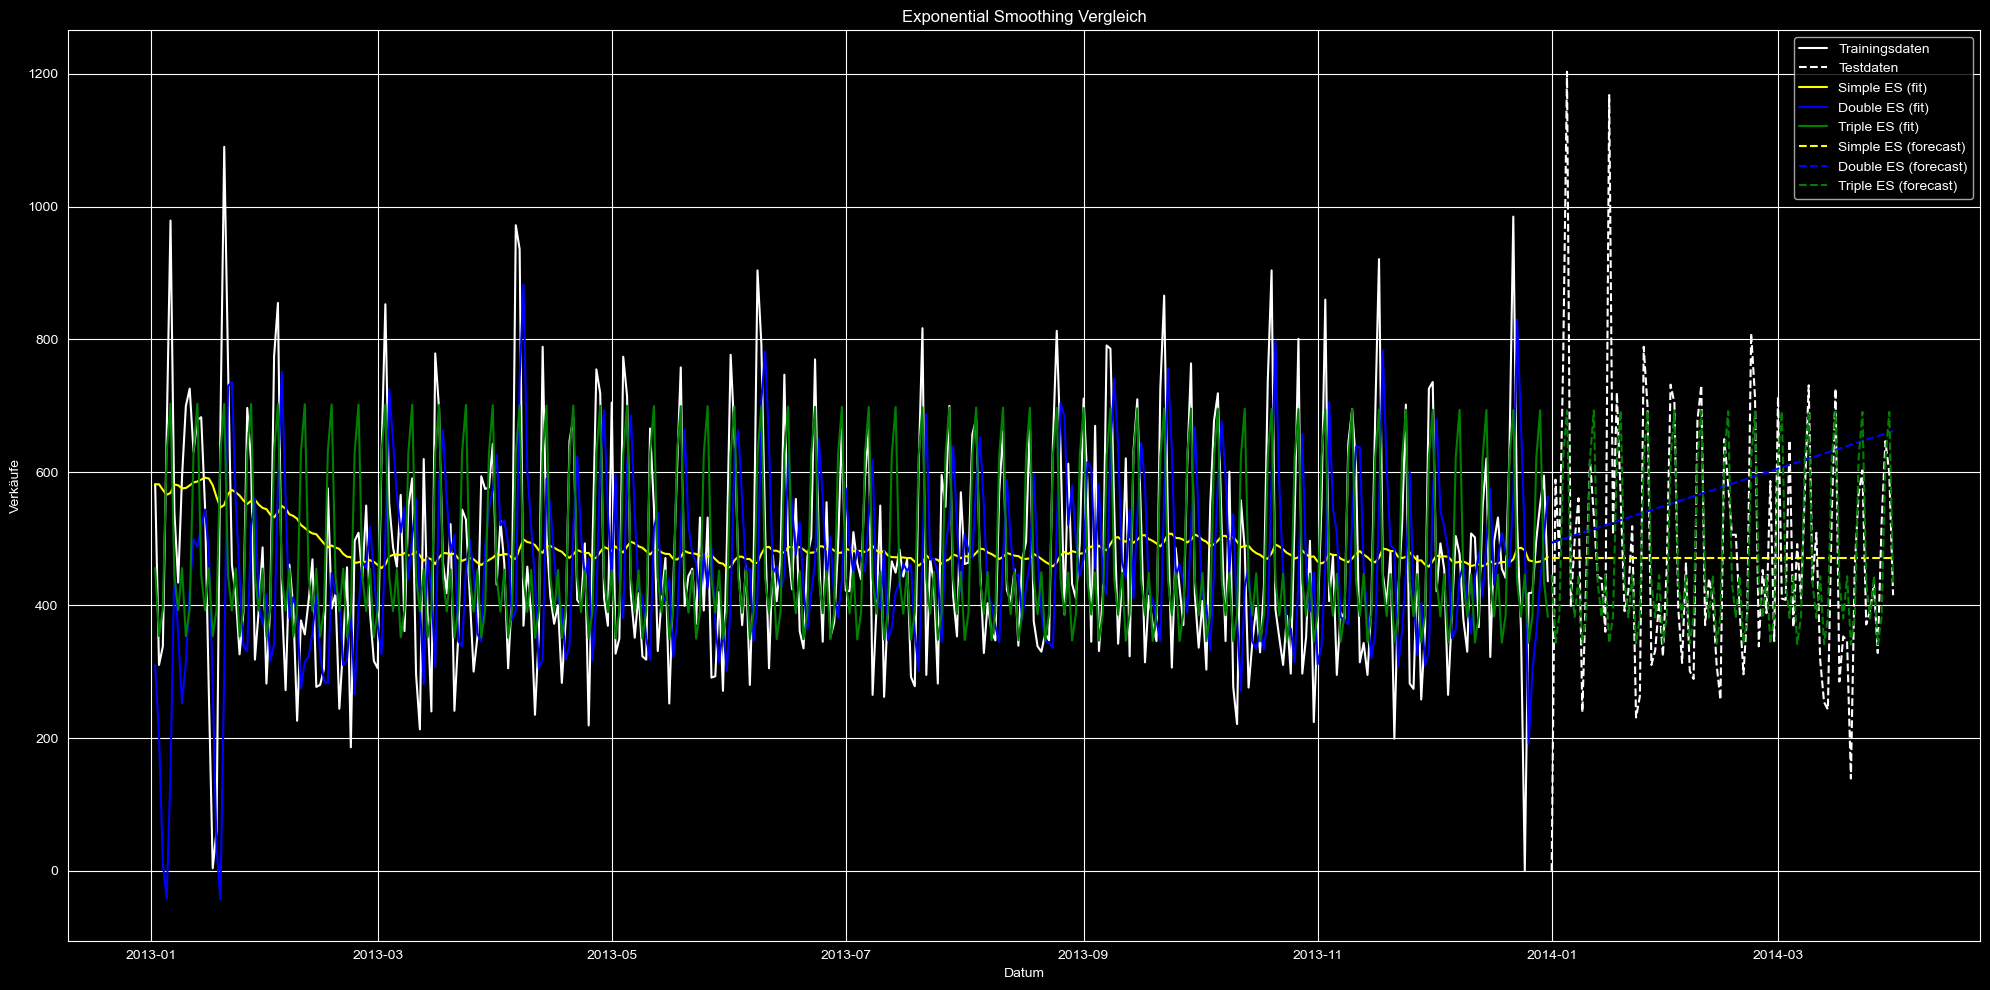

In [12]:
plt.figure(figsize=(20, 10))

# Trainingsdaten
plt.plot(train_data.index, train_data, label='Trainingsdaten', color='white')

# Testdaten
plt.plot(test_data.index, test_data, label='Testdaten', color='white', linestyle='--')

# Gefittete Werte (auf Trainingsdaten)
plt.plot(train_data.index, simple_fitted, label='Simple ES (fit)', color='yellow', linestyle='-')
plt.plot(train_data.index, double_fitted, label='Double ES (fit)', color='blue', linestyle='-')
plt.plot(train_data.index, triple_fitted, label='Triple ES (fit)', color='green', linestyle='-')

# Forecasts (auf Testzeitraum)
plt.plot(simple_forecast.index, simple_forecast, label='Simple ES (forecast)', color='yellow', linestyle='--')
plt.plot(double_forecast.index, double_forecast, label='Double ES (forecast)', color='blue', linestyle='--')
plt.plot(triple_forecast.index, triple_forecast, label='Triple ES (forecast)', color='green', linestyle='--')

plt.legend()
plt.title('Exponential Smoothing Vergleich')
plt.xlabel('Datum')
plt.ylabel('Verkäufe')
plt.tight_layout()
plt.show()

## Evaluierung

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecast-Werte auf Testzeitraum zuschneiden
simple_pred = simple_forecast[:len(test_data)]
double_pred = double_forecast[:len(test_data)]
triple_pred = triple_forecast[:len(test_data)]

actual = test_data['unit_sales'].values

# MAE
print(f"Simple ES  MAE: {mean_absolute_error(actual, simple_pred):.2f}")
print(f"Double ES  MAE: {mean_absolute_error(actual, double_pred):.2f}")
print(f"Triple ES  MAE: {mean_absolute_error(actual, triple_pred):.2f}")
print()

# RMSE
print(f"Simple ES  RMSE: {np.sqrt(mean_squared_error(actual, simple_pred)):.2f}")
print(f"Double ES  RMSE: {np.sqrt(mean_squared_error(actual, double_pred)):.2f}")
print(f"Triple ES  RMSE: {np.sqrt(mean_squared_error(actual, triple_pred)):.2f}")
print()

# AIC
print(f"Simple ES  AIC: {simple_model.aic:.1f}")
print(f"Double ES  AIC: {double_model.aic:.1f}")
print(f"Triple ES  AIC: {triple_model.aic:.1f}")
print()

# BIC
print(f"Simple ES  BIC: {simple_model.bic:.1f}")
print(f"Double ES  BIC: {double_model.bic:.1f}")
print(f"Triple ES  BIC: {triple_model.bic:.1f}")

Simple ES  MAE: 143.97
Double ES  MAE: 183.91
Triple ES  MAE: 98.43

Simple ES  RMSE: 190.57
Double ES  RMSE: 224.96
Triple ES  RMSE: 150.41

Simple ES  AIC: 3749.3
Double ES  AIC: 3900.7
Triple ES  AIC: 3479.6

Simple ES  BIC: 3757.1
Double ES  BIC: 3916.3
Triple ES  BIC: 3522.5


## Interpretation

- Triple ES gewinnt klar – konsistent bestes Ergebnis auf allen Metriken.
- Auffällig: Double ES ist schlechter als Simple ES. Das macht intuitiv Sinn: Die Daten haben keinen Trend – Double ES modelliert aber einen.
- RMSE deutlich größer als MAE → das Modell hat einige größere Ausreißerfehler. Im Schnitt liegt es 98 daneben, aber einzelne Tage weicht es stärker ab
- bestes SARIMA hatte MAE = 97.65 – also praktisch identisch mit Triple ES (98.43). Triple ES erreicht also mit viel weniger Aufwand dasselbe Ergebnis
-
SARIMA vs Triple exponential Smoothing:
- Triple ES → einfacher, schneller, robuster als SARMIA
- SARIMA → flexibler, interpretierbarer, kann komplexere Autokorrelationsstrukturen abbilden
- => In der Praxis gilt oft: Triple ES als starke Baseline, SARIMA wenn man mehr Kontrolle oder bessere Ergebnisse braucht.